# Análisis Exploratorio de Datos (EDA)

## Contexto de los datos

El conjunto de datos utilizado para el análisis es `TCGA_InfoWithGrade.csv`,
correspondiente a una versión preprocesada de los datos relacionados con
gliomas del proyecto The Cancer Genome Atlas (TCGA).

In [1]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import display, HTML



# Dataset
df_mutations = pd.read_csv("dataset/TCGA_InfoWithGrade.csv")
df_mutations.head()

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Variable objetivo

- **`Grade`**: indica el grado del glioma. Esta variable distingue entre
  los dos grupos principales presentes en el conjunto de datos:
  `LGG` (*Low-Grade Glioma*) y `GBM` (*Glioblastoma Multiforme*).

## Variables clínicas

Las variables clínicas proporcionan información sobre las características
demográficas de los pacientes:

- **`Gender`**: género del paciente.
- **`Age_at_diagnosis`**: edad del paciente al momento del diagnóstico.
- **`Race`**: raza reportada del paciente.


## Variables genéticas

El conjunto de datos también contiene variables correspondientes a
diferentes genes. Estas variables están codificadas de forma binaria,
indicando con un valor de **1** la presencia de una mutación en el gen
correspondiente, y con un **0** la ausencia de dicha mutación.


Entre los genes incluidos se encuentran:

- **`IDH1`**: codifica una enzima involucrada en el metabolismo celular.

- **`TP53`**: gen supresor tumoral que participa en el control del ciclo
  celular y en la respuesta al daño del ADN. Sus alteraciones pueden
  favorecer la proliferación de células tumorales.

- **`ATRX`**: participa en el mantenimiento de la estructura de la
  cromatina y en la estabilidad del genoma.

- **`PTEN`**: gen supresor tumoral que regula vías relacionadas con el
  crecimiento y la supervivencia celular.

- **`EGFR`**: codifica un receptor involucrado en señales de crecimiento
  y proliferación celular.

- **`CIC`**: participa en la regulación de la expresión de otros genes y
  en procesos relacionados con el desarrollo celular.

- **`MUC16`**: codifica una proteína de gran tamaño asociada a la
  superficie celular.

- **`PIK3CA`**: participa en la vía de señalización PI3K/AKT, relacionada
  con crecimiento, supervivencia y proliferación celular.

- **`NF1`**: actúa como regulador negativo de señales relacionadas con el
  crecimiento celular. Sus alteraciones pueden contribuir a la
  proliferación tumoral.

- **`PIK3R1`**: codifica una subunidad reguladora de la vía PI3K, que
  interviene en procesos de crecimiento y supervivencia celular.

- **`FUBP1`**: participa en la regulación de la expresión génica y del
  crecimiento celular.

- **`RB1`**: gen supresor tumoral que participa en el control del ciclo
  celular y regula la progresión de las células hacia la división.

- **`NOTCH1`**: forma parte de la vía de señalización Notch, relacionada
  con la diferenciación, proliferación y supervivencia celular.

- **`BCOR`**: participa en la regulación de la expresión génica mediante
  complejos relacionados con la cromatina.

- **`CSMD3`**: codifica una proteína de gran tamaño y se encuentra entre
  los genes que pueden presentar mutaciones en distintos tumores.

- **`SMARCA4`**: participa en la remodelación de la cromatina y, por
  tanto, en la regulación de la expresión de los genes.

- **`GRIN2A`**: codifica una subunidad de un receptor de glutamato,
  relacionado principalmente con la señalización neuronal.

- **`IDH2`**: codifica una enzima metabólica relacionada con IDH1.

- **`FAT4`**: participa en procesos relacionados con la organización,
  adhesión y crecimiento de las células.

- **`PDGFRA`**: codifica un receptor involucrado en señales de
  crecimiento y proliferación celular.


El dataset está compuesto por 24 variables de las cuales 23 son binarias mientras que `Age_at_diagnosis` es númerica (`float64`), expresando  en años la edad del paciente al momento del diagnóstico, donde la parte
decimal incorpora información adicional sobre los días transcurridos.

El objetivo a resolver es predecir la severidad del glioma en pacientes, clasificándolos entre Glioma de Bajo Grado (**LGG**) y Glioblastoma Multiforme (**GBM**) a partir de sus características clínicas y perfil de mutaciones genéticas. Sin embargo, antes de entrenar modelos de clasificación supervisados y realizar la selección óptima de variables, iniciaremos con un análisis exploratorio de datos (EDA) sobre el conjunto de entrenamiento (Train set) derivado del dataset TCGA Glioma. El propósito es comprender la estructura de las variables, identificar los patrones de mutación genéticos más frecuentes, detectar valores atípicos y analizar las relaciones clave entre los biomarcadores clínicos y las alteraciones moleculares que diferencian ambos tipos de tumor.


## Estructura

In [2]:
info_df = pd.DataFrame({
    "Tipo de dato": df_mutations.dtypes.astype(str),
    "Valores no nulos": df_mutations.notna().sum().values,
    "Valores nulos": df_mutations.isna().sum().values
})

info_df

,Tipo de dato,Valores no nulos,Valores nulos
Grade,int64,839,0
Gender,int64,839,0
Age_at_diagnosis,float64,839,0
Race,int64,839,0
IDH1,int64,839,0
TP53,int64,839,0
ATRX,int64,839,0
PTEN,int64,839,0
EGFR,int64,839,0
CIC,int64,839,0


El conjunto de datos presenta una estructura limpia y estructurada, compuesta por **839 registros y 24 variables**, sin presencia de valores nulos o faltantes. Está conformado por una variable continua de tipo flotante correspondiente a la edad al diagnóstico (`Age_at_diagnosis`) y un conjunto de variables categóricas que incluyen la variable objetivo (`Grade`), características demográficas como género y raza, y la presencia o ausencia de mutaciones en los 20 genes analizados. 

Las variables binarias, originalmente codificadas mediante valores enteros `0` y `1`, fueron transformadas al tipo categórico (`category`) para representar adecuadamente su naturaleza y facilitar su análisis exploratorio. Esta estructura tabular compacta permite realizar de manera eficiente el análisis exploratorio de datos, la visualización de patrones y las posteriores etapas de ingeniería de características y modelado predictivo.

In [3]:
# Conversión de columnas categóricas a tipo "category"

columnas_categoricas = df_mutations.columns.difference(["Age_at_diagnosis"])
df_mutations[columnas_categoricas] = df_mutations[columnas_categoricas].astype("category")

pd.DataFrame({
    "Tipo": df_mutations.dtypes.astype(str)
}).T

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
Tipo,category,category,float64,category,category,category,category,category,category,category,...,category,category,category,category,category,category,category,category,category,category


## Missing data

A continuación se revisan los valores faltantes y las principales
estadísticas descriptivas del conjunto de datos.

In [4]:
print("Valores faltantes:")
display(df_mutations.isnull().sum().sum())

Valores faltantes:


0

El conjunto de datos no presenta datos faltantes.

## División del dataset

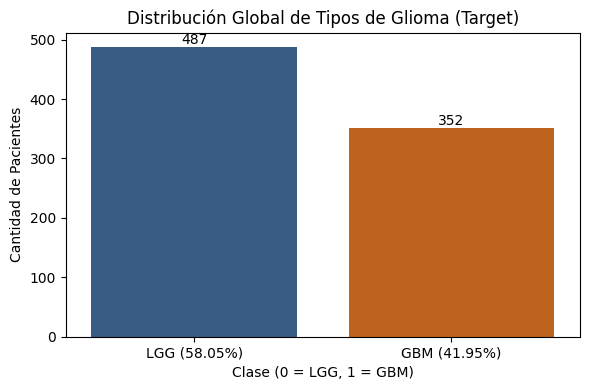

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

conteo = df_mutations['Grade'].value_counts()
proporcion = df_mutations['Grade'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_mutations, x='Grade', palette=['#2b5c8f', '#d95f02'])
plt.title('Distribución Global de Tipos de Glioma (Target)')
plt.xlabel('Clase (0 = LGG, 1 = GBM)')
plt.ylabel('Cantidad de Pacientes')
plt.xticks(ticks=[0, 1], labels=['LGG (58.05%)', 'GBM (41.95%)'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

La elección de una partición estratificada (Stratified Train-Test Split) se justifica por la necesidad de preservar la proporción original de las clases de la variable objetivo (Grade) en ambos subconjuntos de datos. En el dataset completo, la distribución presenta un ligero desbalance, donde el 58.05% corresponde a Gliomas de Bajo Grado (LGG) y el 41.95% a Glioblastomas (GBM), una división sin estratificar podría dejar los conjuntos de `train` y `test` sesgados a un solo grupo de la variable `Grade`.

In [6]:
from sklearn.model_selection import train_test_split

x = df_mutations.drop(columns=['Grade'])
y = df_mutations['Grade']

X_train, X_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)

Para asegurar una evaluación rigurosa del modelo y prevenir la fuga de datos, el conjunto original de 839 registros se dividió en una proporción 80/20 mediante una partición estratificada basada en la variable objetivo (`Grade`). De este modo, se reservó un conjunto de prueba (*Test set*) compuesto por 168 pacientes exclusivamente para la validación final del rendimiento, mientras que las 671 observaciones restantes formaron el conjunto de entrenamiento (*Train set*), garantizando que el patrón de distribución de las clases —aproximadamente 58% para tumores de bajo grado (LGG) y 42% para glioblastomas (GBM)— se mantuviera perfectamente balanceado entre ambas subdivisiones.

## Análisis Univariado

### Variable `Grade` (Target)

Resumen estadístico de la variable objetivo:

### Variables cuantitativas

Resumen estadístico de la variable `Age_at_diagnosis`:

### Variables cualitativas

Para las variables categóricas se realizó un análisis univariado basado en sus frecuencias absolutas y relativas. Para cada variable se presenta una tabla con el número de observaciones y el porcentaje correspondiente a cada categoría, acompañada de su respectivo gráfico de barras de frecuencia. Esta representación permite visualizar y comparar la distribución de las categorías, así como identificar aquellas con mayor o menor presencia dentro del conjunto de datos.

#### `Gender`

La distribución por género muestra un ligero predominio de hombres, correspondientes a la categoría `0`, con 398 registros **(59,31 %)**. Por su parte, las mujeres, representadas por la categoría `1`, corresponden a 273 registros **(40,69 %)**.

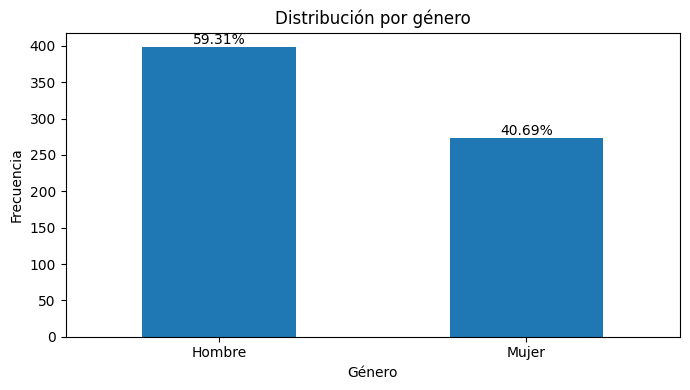

Género,Frecuencia,Porcentaje
Hombre,398,59.31
Mujer,273,40.69


In [7]:
# Tabla
tabla_gender = (
    train_data["Gender"]
    .value_counts()
    .rename_axis("Género")
    .reset_index(name="Frecuencia")
)

tabla_gender["Porcentaje"] = (
    tabla_gender["Frecuencia"] /
    tabla_gender["Frecuencia"].sum() * 100
).round(2)

tabla_gender["Género"] = tabla_gender["Género"].map({
    0: "Hombre",
    1: "Mujer"
})


# Gráfico
frecuencias_gender = (
    train_data["Gender"]
    .value_counts()
    .sort_index()
)

frecuencias_gender.index = ["Hombre", "Mujer"]

plt.figure(figsize=(7, 4))

ax = frecuencias_gender.plot(kind="bar")

plt.title("Distribución por género")
plt.xlabel("Género")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)

for i, porcentaje in enumerate(tabla_gender["Porcentaje"]):
    ax.text(
        i,
        frecuencias_gender.iloc[i] + 5,
        f"{porcentaje:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

tabla_html = tabla_gender.to_html(index=False)

tabla_html = tabla_html.replace(
    "<table",
    '<table style="margin-top: 30px;"'
)

display(HTML(tabla_html))

#### `Race`

En cuanto a la variable `Race`, se observa una marcada concentración de los registros en la categoría **White**, que representa 611 casos **(91,06 %)** del conjunto analizado. La categoría **Black or African American** cuenta con 46 registros **(6,86 %)**, mientras que **Asian** representa 13 casos **(1,94 %)**. Finalmente, **American Indian or Alaska Native** presenta únicamente 1 registro **(0,15 %)**.

La distribución evidencia un fuerte desbalance en la variable racial, dado que la categoría de personas de raza blanca concentra más de nueve de cada diez observaciones. Por tanto, las categorías minoritarias tienen una representación considerablemente menor dentro del conjunto de datos.

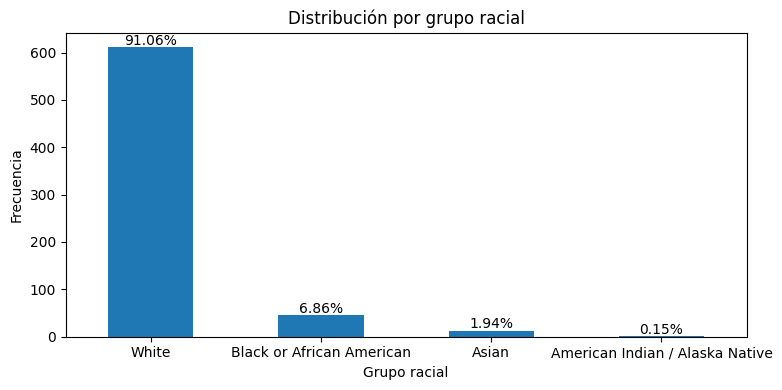

Grupo racial,Frecuencia,Porcentaje
White,611,91.06
Black or African American,46,6.86
Asian,13,1.94
American Indian or Alaska Native,1,0.15


In [8]:
# Tabla
tabla_race = (
    train_data["Race"]
    .value_counts()
    .rename_axis("Grupo racial")
    .reset_index(name="Frecuencia")
)

tabla_race["Porcentaje"] = (
    tabla_race["Frecuencia"] /
    tabla_race["Frecuencia"].sum() * 100
).round(2)

tabla_race["Grupo racial"] = tabla_race["Grupo racial"].map({
    0: "White",
    1: "Black or African American",
    2: "Asian",
    3: "American Indian or Alaska Native"
})


# Gráfico
frecuencias_race = (
    train_data["Race"]
    .value_counts()
    .sort_index()
)

frecuencias_race.index = [
    "White",
    "Black or African American",
    "Asian",
    "American Indian / Alaska Native"
]

plt.figure(figsize=(8, 4))

ax = frecuencias_race.plot(kind="bar")

plt.title("Distribución por grupo racial")
plt.xlabel("Grupo racial")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)

for i, porcentaje in enumerate(tabla_race["Porcentaje"]):
    ax.text(
        i,
        frecuencias_race.iloc[i] + 5,
        f"{porcentaje:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

tabla_html = tabla_race.to_html(index=False)

tabla_html = tabla_html.replace(
    "<table",
    '<table style="margin-top: 30px;"'
)

display(HTML(tabla_html))

#### `Variables genéticas`

Las variables genéticas presentan una distribución predominantemente concentrada en la categoría `0`, correspondiente a la ausencia de mutación, mientras que la categoría `1` representa su presencia. 

Entre los genes analizados, **IDH1** presenta la mayor proporción de casos con mutación, con 322 registros **(47,99 %)**, seguido de **TP53**, con 270 registros **(40,24 %)**. A continuación se encuentran **ATRX** con **25,63 %**, **PTEN** con **16,84 %**, **CIC** con **13,71 %**, **EGFR** con **11,62 %** y **MUC16** con **11,03 %**. En un nivel intermedio se encuentran **PIK3CA (8,49 %)**, **NF1 (8,35 %)** y **FUBP1 (6,26 %)**, mientras que **PIK3R1 (5,81 %)**, **RB1 (4,92 %)** y **NOTCH1 (4,92 %)** presentan proporciones inferiores al 6 %. Finalmente, genes como **CSMD3 (3,43 %)**, **SMARCA4 (3,43 %)**, **IDH2 (3,13 %)**, **BCOR (3,28 %)**, **GRIN2A (2,83 %)**, **FAT4 (2,68 %)** y **PDGFRA (2,68 %)** muestran una presencia de mutaciones relativamente baja en el conjunto analizado. 

En términos generales, se observa una alta variabilidad en la frecuencia de las mutaciones entre los genes, con una mayor concentración en IDH1 y TP53 y una presencia considerablemente menor en los genes restantes. Esto evidencia que las alteraciones genéticas no se distribuyen de manera uniforme en la muestra y que algunos genes presentan una representación mutacional mucho mayor que otros.

Categoría,Frecuencia,Porcentaje
0,349,52.01
1,322,47.99
Categoría,Frecuencia,Porcentaje
0,401,59.76
1,270,40.24
Categoría,Frecuencia,Porcentaje
0,499,74.37
1,172,25.63
Categoría,Frecuencia,Porcentaje
0,558,83.16

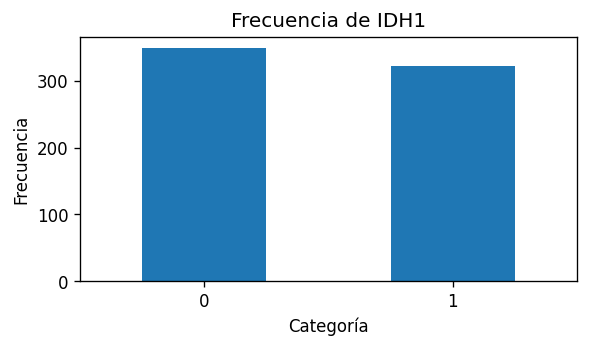
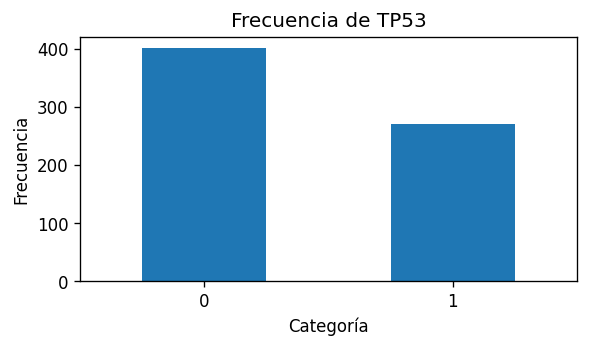
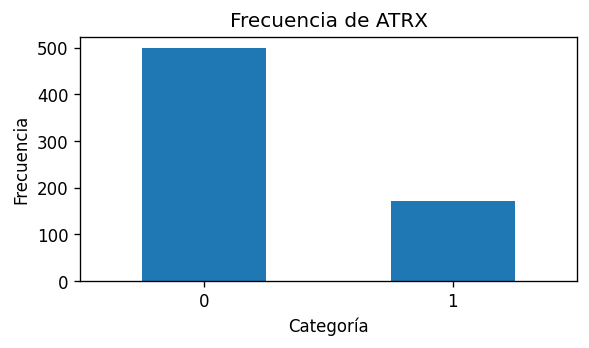
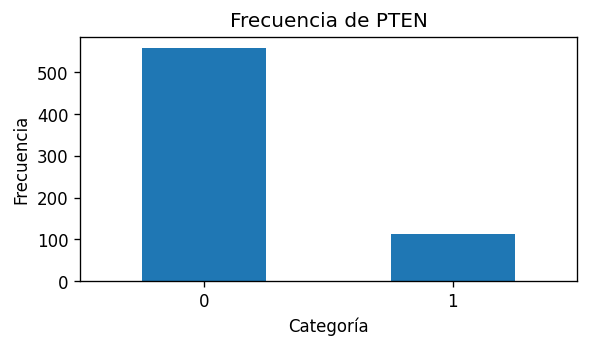
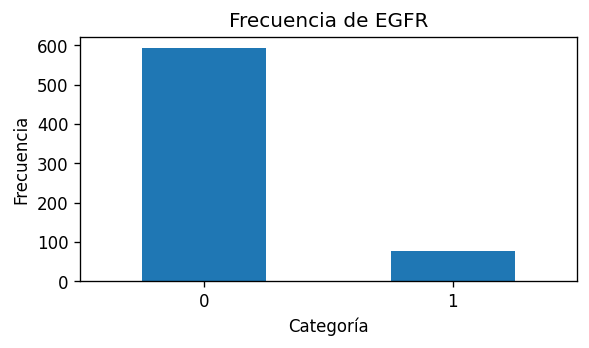
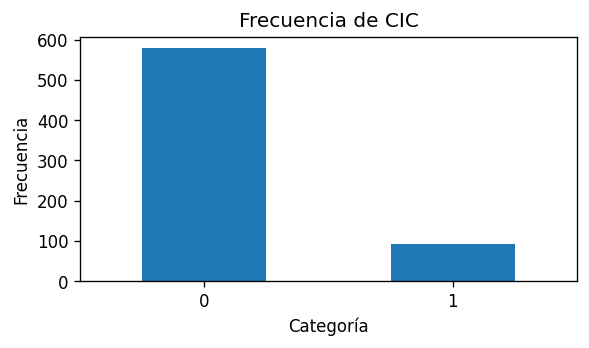
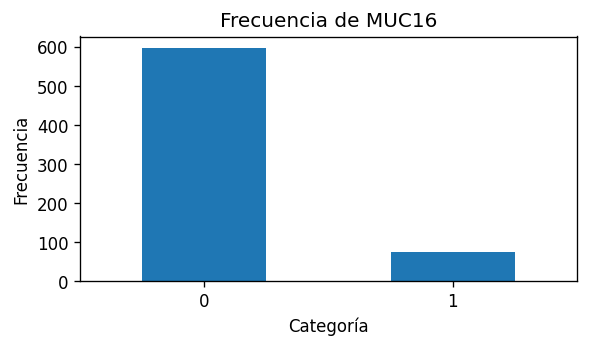
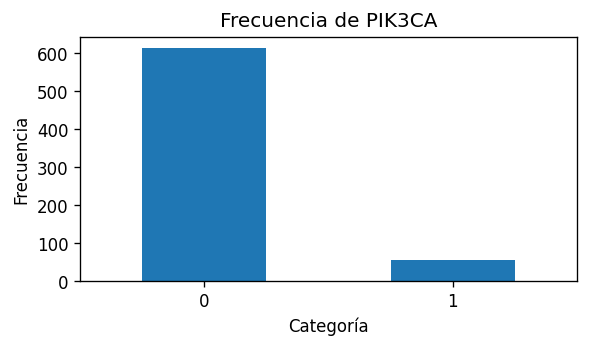
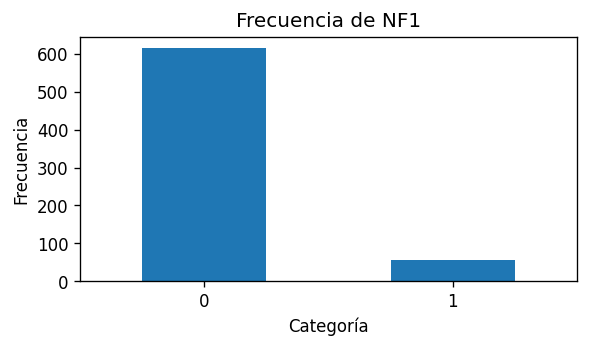
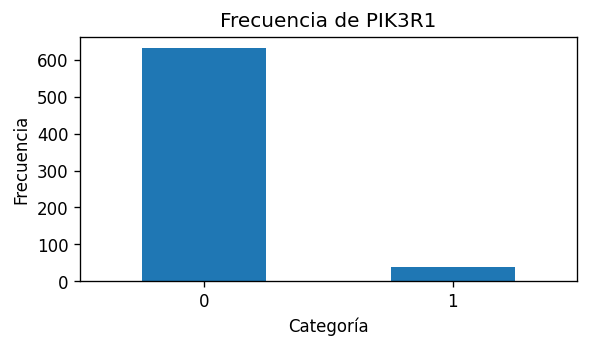
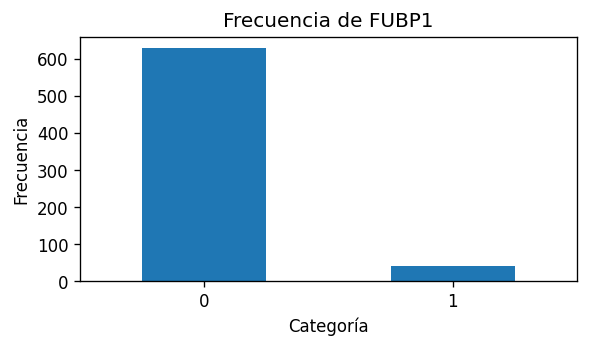
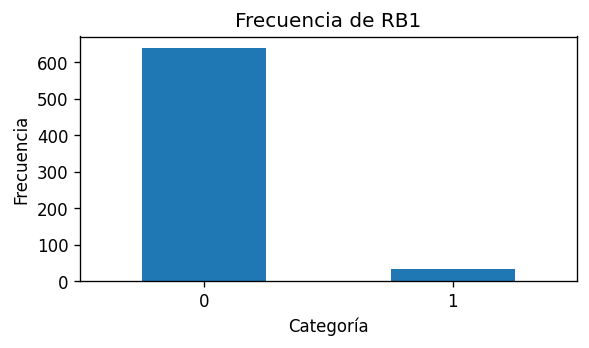
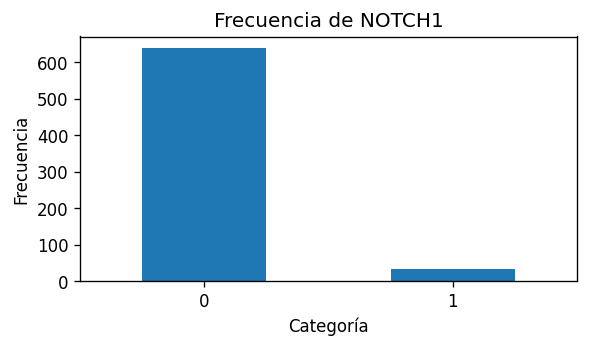
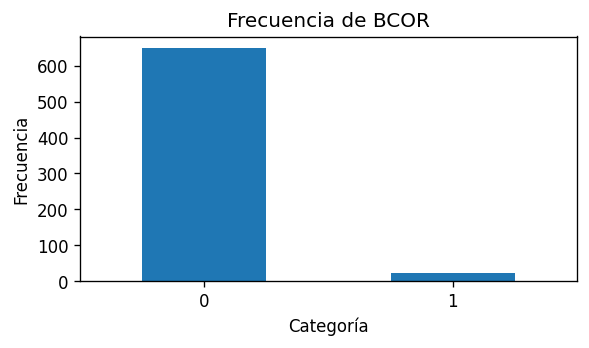
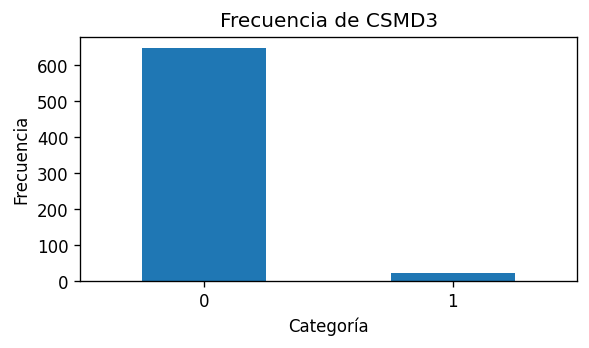
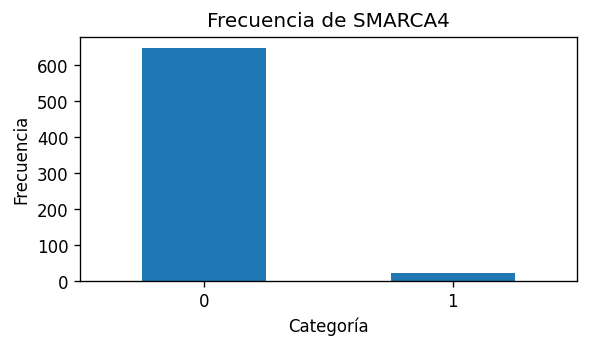
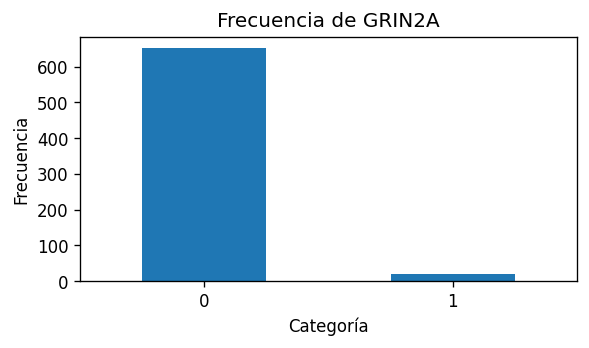
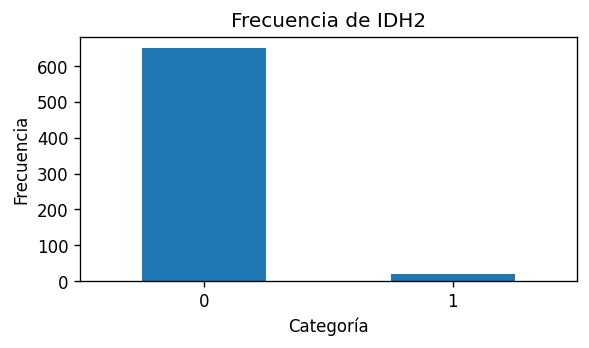
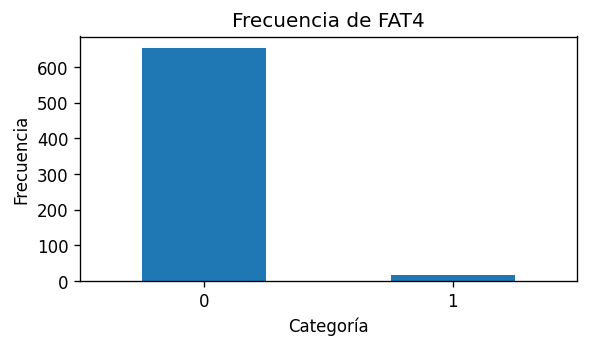
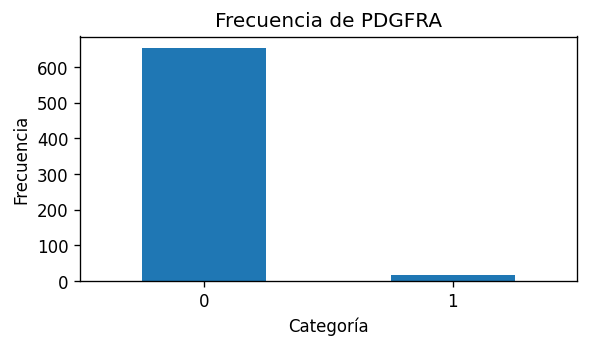

In [9]:
variables_categoricas = train_data.select_dtypes(
    include=["category"]
).columns.drop(["Grade", "Gender", "Race"])

bloques = []

for variable in variables_categoricas:

    # Tabla de frecuencias
    tabla = (
        train_data[variable]
        .value_counts(dropna=False)
        .rename_axis("Categoría")
        .reset_index(name="Frecuencia")
    )

    tabla["Porcentaje"] = (
        tabla["Frecuencia"] / tabla["Frecuencia"].sum() * 100
    ).round(2)

    html_tabla = tabla.to_html(
        index=False,
        classes="tabla-categorica"
    )

    # Gráfico de barras
    frecuencias = train_data[variable].value_counts(dropna=False)

    fig, ax = plt.subplots(figsize=(5, 3))

    frecuencias.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"Frecuencia de {variable}")
    ax.set_xlabel("Categoría")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()

    buffer = io.BytesIO()
    fig.savefig(
        buffer,
        format="png",
        dpi=120,
        bbox_inches="tight"
    )
    plt.close(fig)

    imagen_base64 = base64.b64encode(
        buffer.getvalue()
    ).decode()

    bloque = f"""
    <div style="
        padding: 15px;
        border-radius: 8px;
        margin-bottom: 20px;
    ">

        <h4 style="margin-bottom: 10px;">
            {variable}
        </h4>

        <!-- FILA: TABLA -->
        <div style="
            margin-bottom: 15px;
        ">
            {html_tabla}
        </div>

        <!-- FILA: GRÁFICO -->
        <div style="
            text-align: center;
        ">
            <img
                src="data:image/png;base64,{imagen_base64}"
                style="max-width: 100%;"
            >
        </div>

    </div>
    """

    bloques.append(bloque)

html_final = f"""
<div style="
    display: grid;
    grid-template-columns: repeat(2, 1fr);
    gap: 30px;
    margin-top: 20px;
">
    {''.join(bloques)}
</div>
"""

display(HTML(html_final))

## Análisis Bivariado

En esta sección se analiza la relación entre las variables categóricas independientes y la variable objetivo `Grade`. Para cada variable se comparan las frecuencias absolutas y relativas de sus categorías dentro de cada nivel de `Grade`, con el propósito de identificar posibles diferencias en su distribución según la variable objetivo. Las comparaciones se complementan mediante gráficos de barras agrupadas, facilitando la interpretación visual de los patrones observados.

In [10]:
def analisis_bivariado(df, target, variable, etiquetas=None, titulo=None, xlabel=None):

    df_plot = (
        df
        .groupby([target, variable])
        .size()
        .reset_index(name="n")
    )

    df_plot["categoria"] = df_plot[variable]
    
    df_plot["porcentaje"] = (
        df_plot["n"] /
        df_plot.groupby(target)["n"].transform("sum") * 100
    ).round(1)

    df_plot = df_plot[
        [target, "categoria", "n", "porcentaje"]
    ]

    if etiquetas is not None:
        df_plot["categoria"] = df_plot["categoria"].map(etiquetas)



    categorias = sorted(df_plot["categoria"].unique())
    grupos = sorted(df_plot[target].unique())

    x = np.arange(len(categorias))
    ancho = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, grupo in enumerate(grupos):

        datos = (
            df_plot[df_plot[target] == grupo]
            .set_index("categoria")
            .reindex(categorias)
        )

        posiciones = (
            x + (i - (len(grupos) - 1) / 2) * ancho
        )

        barras = ax.bar(
            posiciones,
            datos["n"],
            width=ancho,
            label=f"{target} {grupo}"
        )

        for barra, n, porcentaje in zip(
            barras,
            datos["n"],
            datos["porcentaje"]
        ):
            if not np.isnan(n):
                ax.text(
                    barra.get_x() + barra.get_width() / 2,
                    barra.get_height() + 3,
                    f"{int(n)} ({porcentaje:.1f}%)",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )


    if titulo is None:
        titulo = f"Distribución de {variable} según {target}"

    if xlabel is None:
        xlabel = variable

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Cantidad de pacientes")

    ax.set_xticks(x)
    ax.set_xticklabels(categorias)

    ax.legend(title=target)

    plt.tight_layout()
    plt.show()

    return df_plot

### `Grade` - `Gender`

La distribución del género presenta diferencias entre los dos niveles de Grade. En Grade 0, se registran 220 hombres (56,6%) y 169 mujeres (43,4%), mientras que en Grade 1 se observan 178 hombres (63,1%) y 104 mujeres (36,9%). En ambos niveles predomina el género masculino; sin embargo, esta predominancia es mayor en Grade 1, donde los hombres representan el 63,1% frente al 56,6% en Grade 0. Por otro lado, la proporción de mujeres disminuye de 43,4% en Grade 0 a 36,9% en Grade 1. En términos descriptivos, estos resultados sugieren una mayor representación masculina en Grade 1, aunque las diferencias observadas no permiten establecer por sí solas una asociación estadísticamente significativa entre el género y Grade.

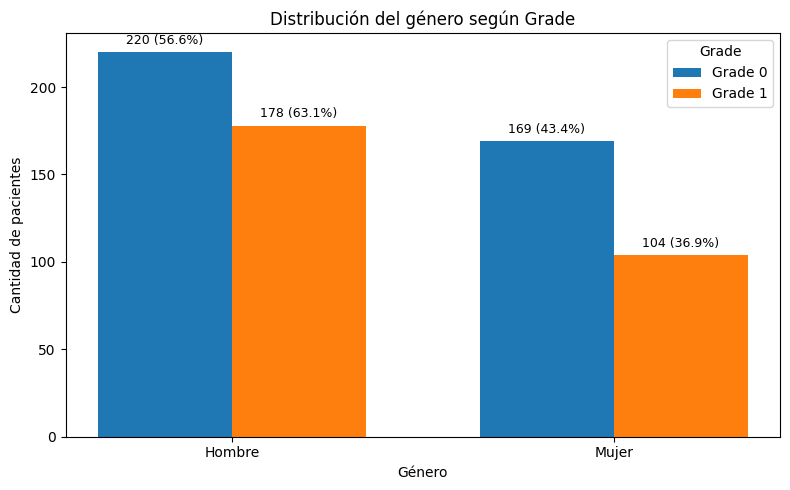

In [11]:
tabla_gender_bivariada = analisis_bivariado(
    train_data,
    target="Grade",
    variable="Gender",
    etiquetas={
        0: "Hombre",
        1: "Mujer"
    },
    titulo="Distribución del género según Grade",
    xlabel="Género"
)

### `Grade` - `Race`

La distribución por grupo racial muestra un predominio marcado de la población blanca en ambos niveles de Grade. En Grade 0, el grupo White concentra 365 pacientes (93,8%), mientras que en Grade 1 representa 246 pacientes (87,2%). El grupo Black or African American constituye el segundo grupo con mayor representación, con 16 pacientes (4,1%) en Grade 0 y 30 pacientes (10,6%) en Grade 1. Por su parte, la población asiática presenta una participación reducida, con 7 casos (1,8%) en Grade 0 y 6 casos (2,1%) en Grade 1, mientras que American Indian or Alaska Native presenta una presencia prácticamente nula, con 1 caso (0,3%) en Grade 0 y ningún caso en Grade 1**.**

En términos comparativos, se observa que la proporción del grupo White disminuye en Grade 1, pasando de 93,8% a 87,2%, mientras que el grupo Black or African American aumenta de 4,1% a 10,6%.

Adem'as, si bien existen diferencias en la distribución de los grupos raciales entre los niveles de Grade, estos resultados deben analizarse con precaución, ya que la muestra está fuertemente concentrada en el grupo White y algunas de las demás categorías presentan muy pocas observaciones.

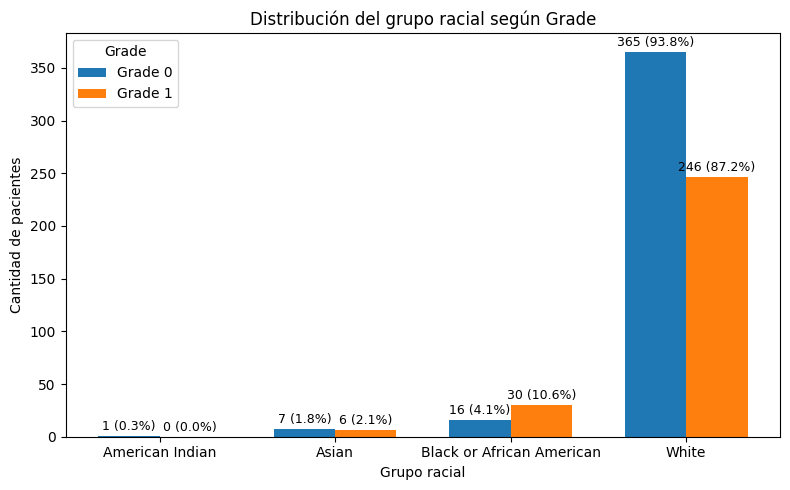

In [12]:
tabla_race_bivariada = analisis_bivariado(
    train_data,
    target="Grade",
    variable="Race",
    etiquetas={
        0: "White",
        1: "Black or African American",
        2: "Asian",
        3: "American Indian"
    },
    titulo="Distribución del grupo racial según Grade",
    xlabel="Grupo racial"
)

### `Grade` - `IDH1`

Al comparar la presencia de la mutación en IDH1 entre los dos niveles de Grade, se observa una diferencia bastante marcada. En los LGG (Grade 0), 303 pacientes (77,9%) presentan la mutación de IDH1, mientras que 86 pacientes (22,1%) no presentan la mutación. En contraste, en los GBM (Grade 1), solamente 19 pacientes (6,7%) presentan la mutación, mientras que 263 pacientes (93,3%) no la presentan.

Esto muestra un patrón muy marcado donde la mutación de IDH1 es mucho más frecuente en los LGG que en los GBM. En los LGG, aproximadamente 8 de cada 10 pacientes presentan la mutación, mientras que en los GBM ocurre en aproximadamente 7 de cada 100 pacientes. Por el contrario, la ausencia de la mutación predomina ampliamente en los GBM.

Desde una perspectiva descriptiva, estos resultados sugieren que la presencia de la mutación IDH1 está fuertemente asociada con los LGG en este conjunto de datos, mientras que su ausencia caracteriza en mayor proporción a los GBM.

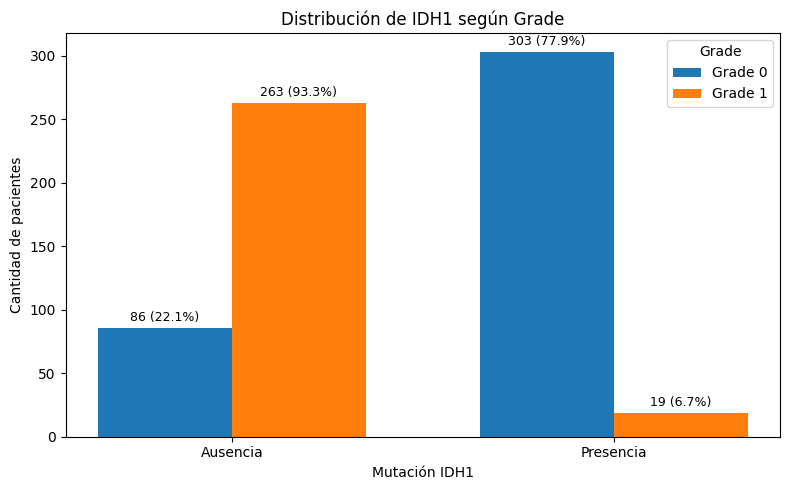

In [13]:
tabla_IDH1_bivariada = analisis_bivariado(
    train_data,
    target="Grade",
    variable="IDH1",
    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },
    titulo="Distribución de IDH1 según Grade",
    xlabel="Mutación IDH1"
)

### `Grade` - `TP53`

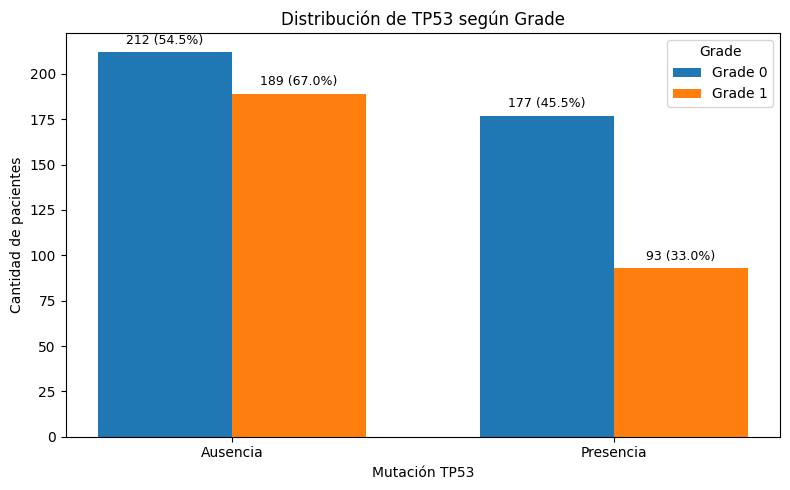

In [14]:
tabla_TP53_bivariada = analisis_bivariado(
    train_data,
    target="Grade",
    variable="TP53",
    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },
    titulo="Distribución de TP53 según Grade",
    xlabel="Mutación TP53"
)

In [15]:
def resumen_bivariado(df, target, variable, etiquetas):

    df_plot = (
        df
        .groupby([target, variable])
        .size()
        .reset_index(name="n")
    )

    df_plot["categoria"] = df_plot[variable].map(etiquetas)

    df_plot["porcentaje"] = (
        df_plot["n"] /
        df_plot.groupby(target)["n"].transform("sum") * 100
    ).round(1)

    return df_plot[[target, "categoria", "n", "porcentaje"]]


def graficar_bivariado_base64(df_plot, target, variable, titulo, xlabel):

    categorias = list(df_plot["categoria"].dropna().unique())
    grupos = sorted(df_plot[target].unique())

    x = np.arange(len(categorias))
    ancho = 0.8 / len(grupos)

    fig, ax = plt.subplots(figsize=(6.5, 4.3))

    for i, grupo in enumerate(grupos):

        datos = (
            df_plot[df_plot[target] == grupo]
            .set_index("categoria")
            .reindex(categorias)
        )

        posiciones = x + (i - (len(grupos) - 1) / 2) * ancho

        barras = ax.bar(posiciones, datos["n"], width=ancho, label=f"{target} {grupo}")

        for barra, n, porcentaje in zip(barras, datos["n"], datos["porcentaje"]):
            if not np.isnan(n):
                ax.text(
                    barra.get_x() + barra.get_width() / 2,
                    barra.get_height() + 2,
                    f"{int(n)} ({porcentaje:.0f}%)",
                    ha="center", va="bottom", fontsize=10
                )

    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Pacientes", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(categorias, fontsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.legend(title=target, fontsize=10)

    plt.tight_layout()

    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig)

    return base64.b64encode(buffer.getvalue()).decode()


def generar_interpretacion(df_plot, target, variable, categoria_presencia="Presencia"):

    grupos = sorted(df_plot[target].unique())

    pct = {
        g: df_plot[
            (df_plot[target] == g) & (df_plot["categoria"] == categoria_presencia)
        ]["porcentaje"].values[0]
        for g in grupos
    }

    g_max = max(pct, key=pct.get)
    diff = abs(pct[grupos[0]] - pct[grupos[1]])

    if diff >= 30:
        fuerza = "una asociación marcada"
    elif diff >= 15:
        fuerza = "una asociación moderada"
    else:
        fuerza = "una asociación débil"

    texto = (
        f"Presente en el <b>{pct[grupos[0]]:.1f}%</b> de los pacientes con {target} {grupos[0]} "
        f"y en el <b>{pct[grupos[1]]:.1f}%</b> con {target} {grupos[1]}, lo que sugiere {fuerza} "
        f"(diferencia de {diff:.1f} puntos porcentuales), siendo más frecuente en {target} {g_max}."
    )

    return texto, diff



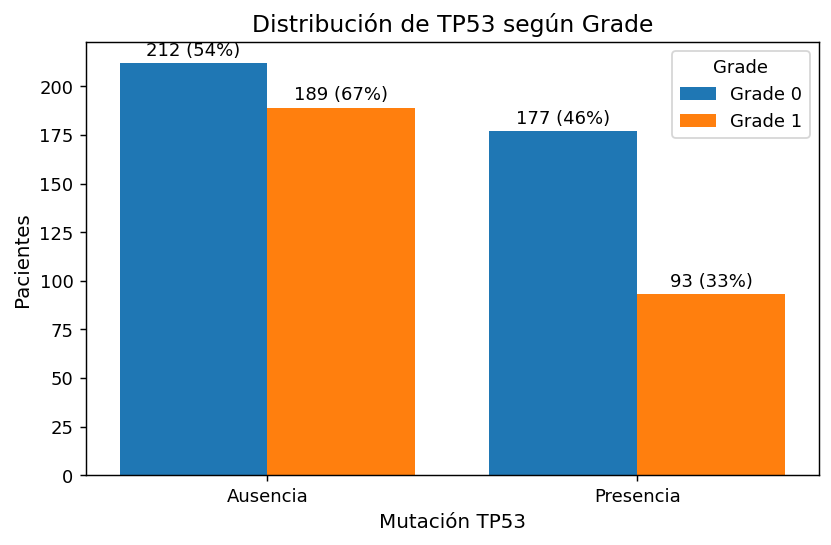
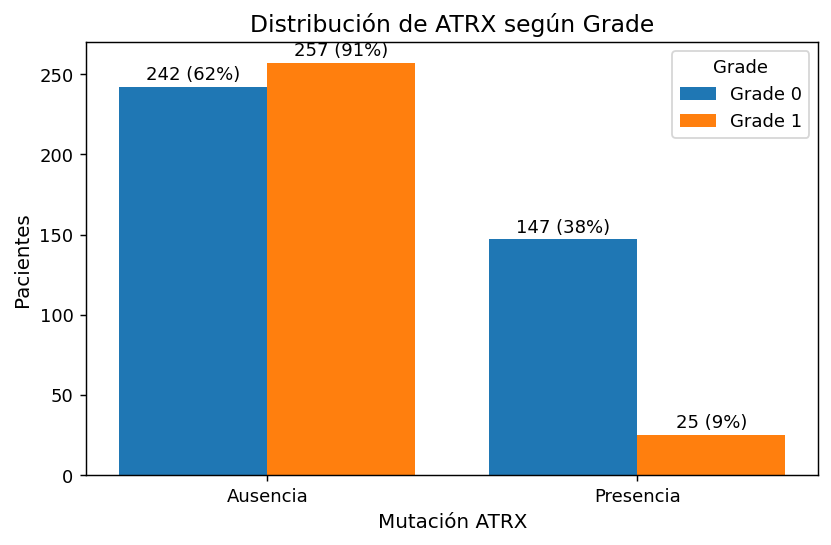
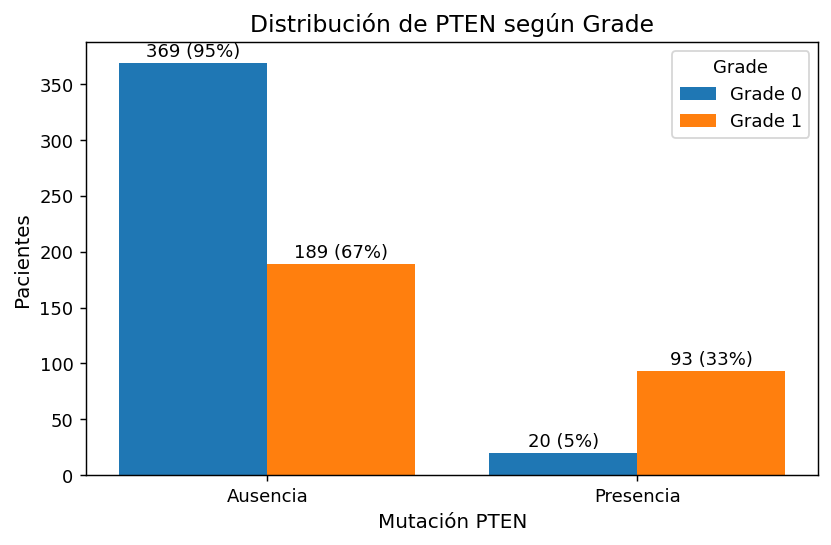
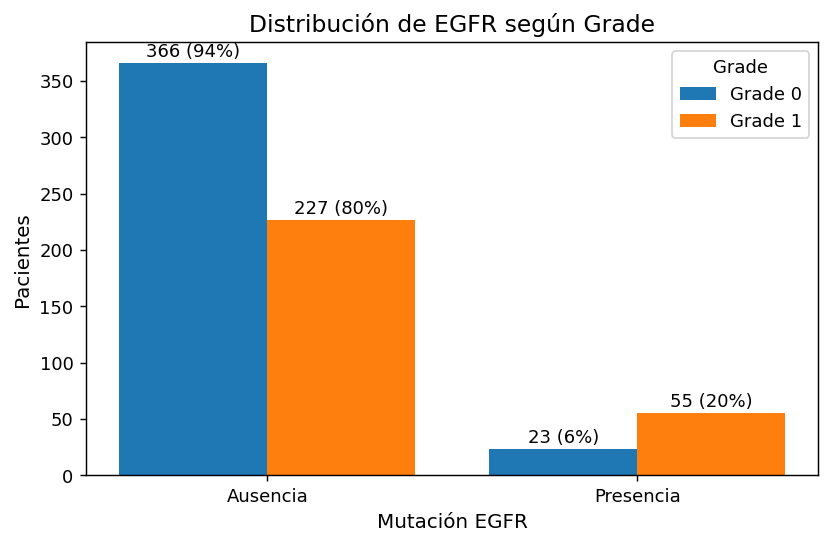
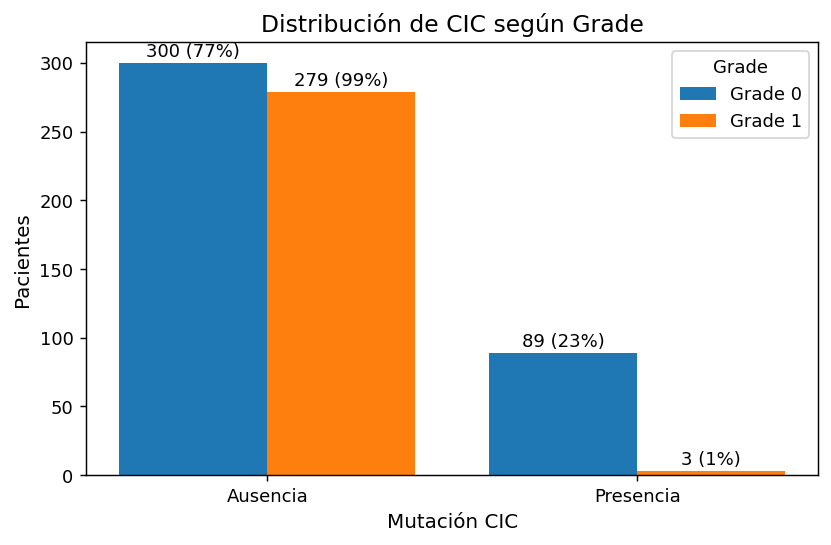
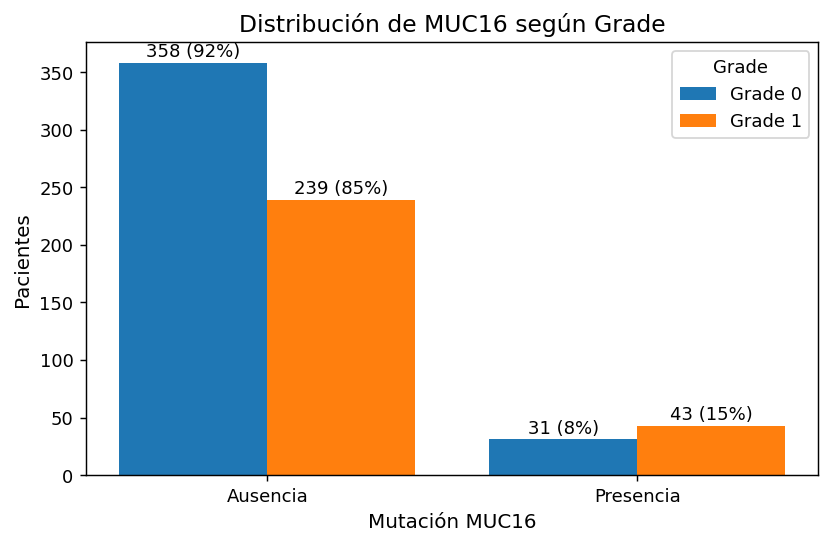
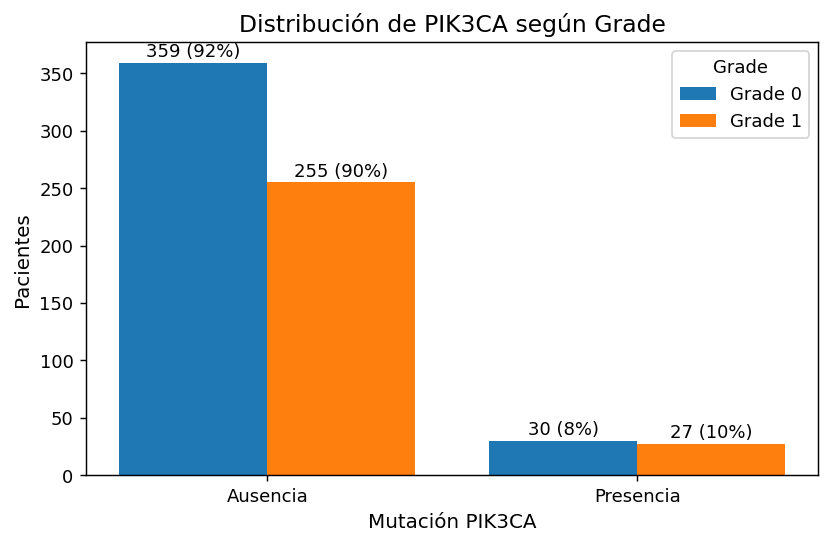
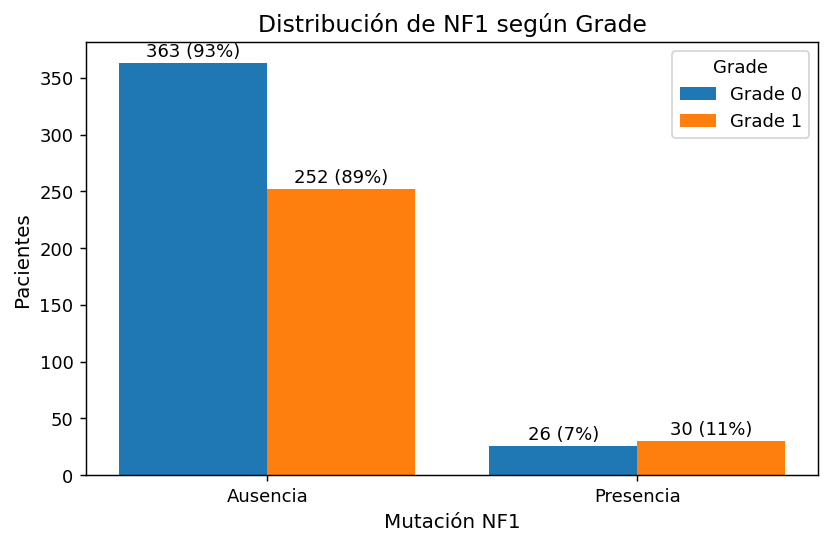
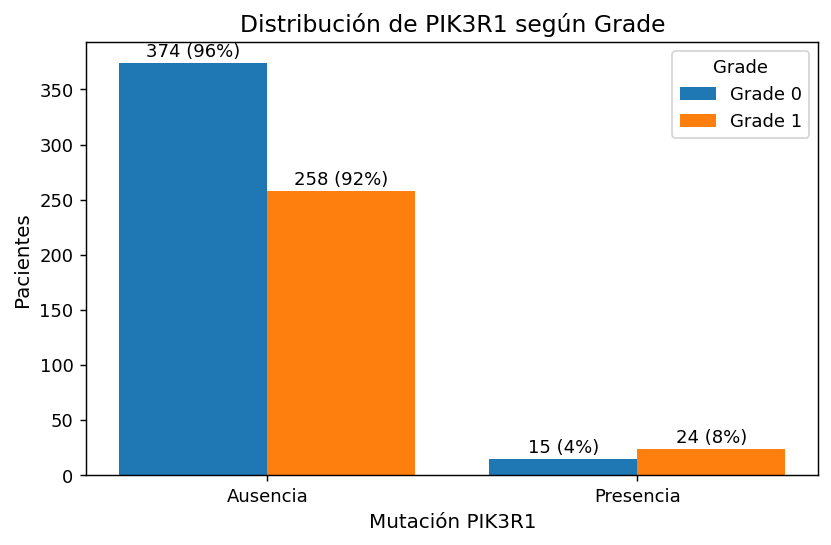
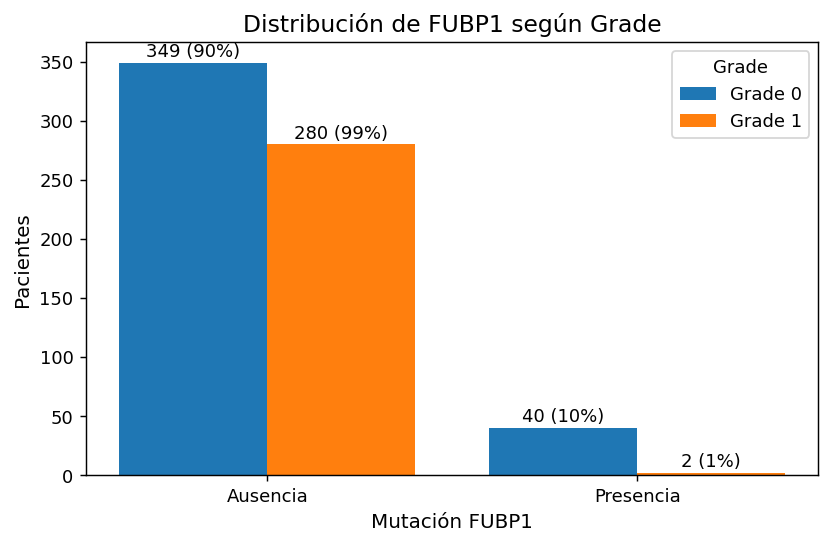
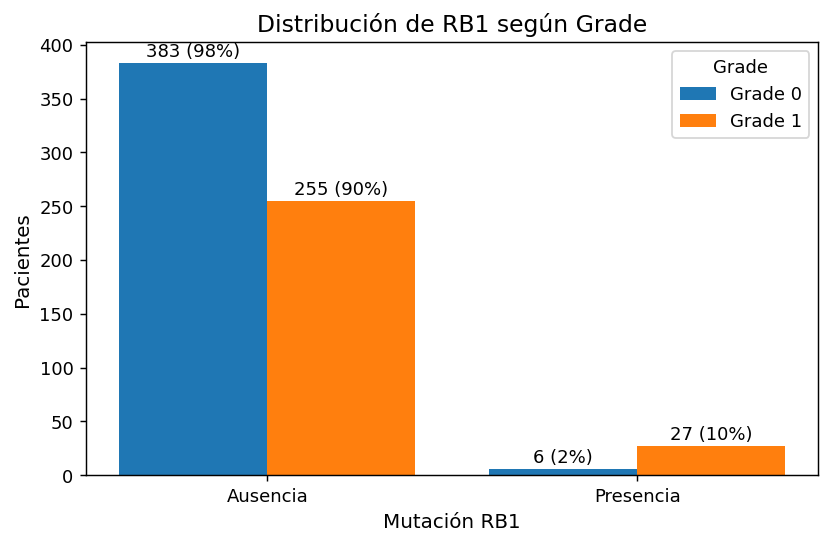
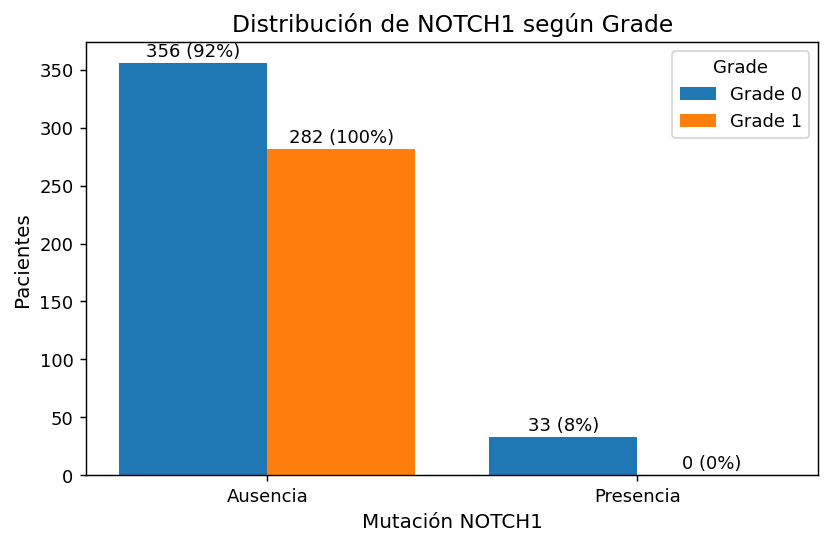
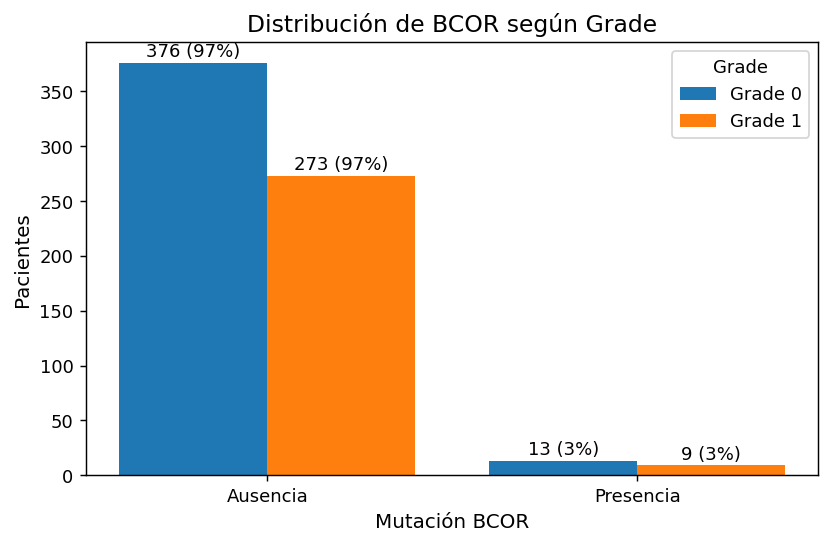
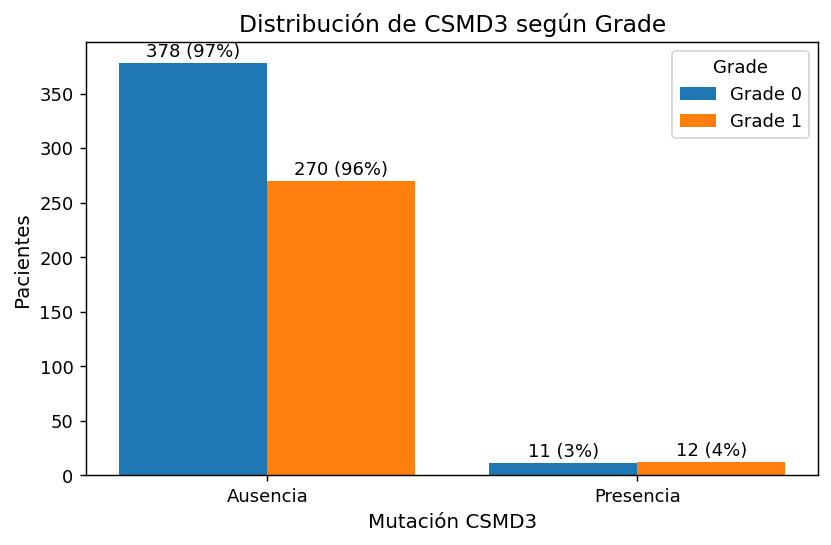
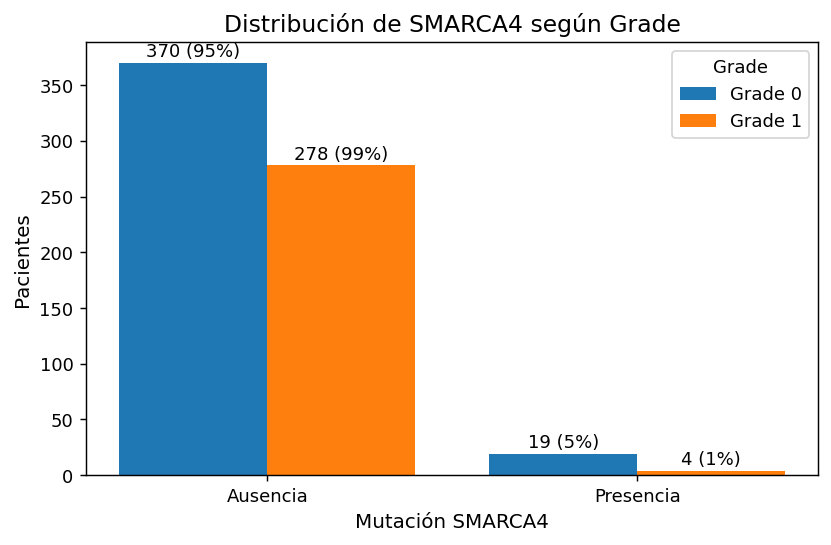
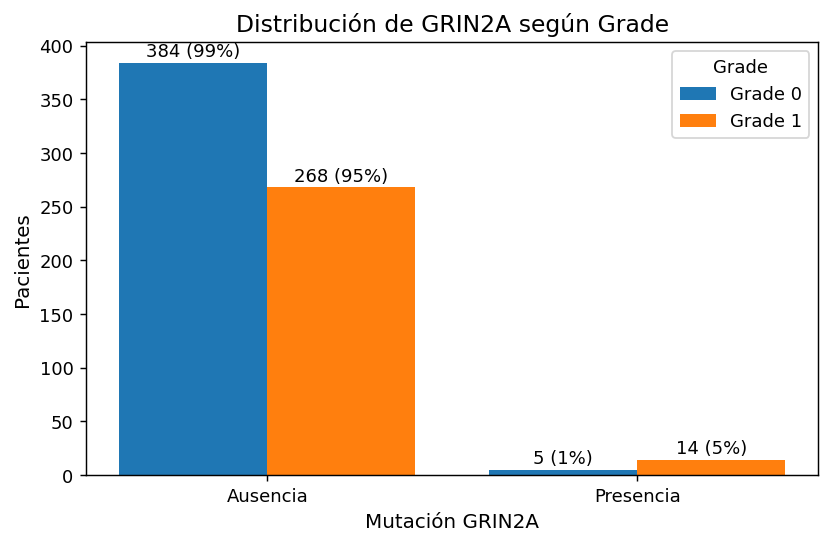
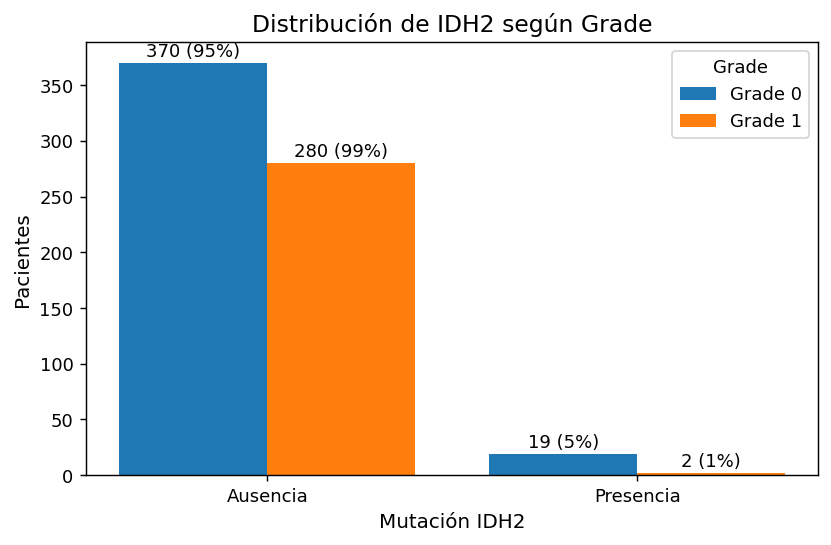
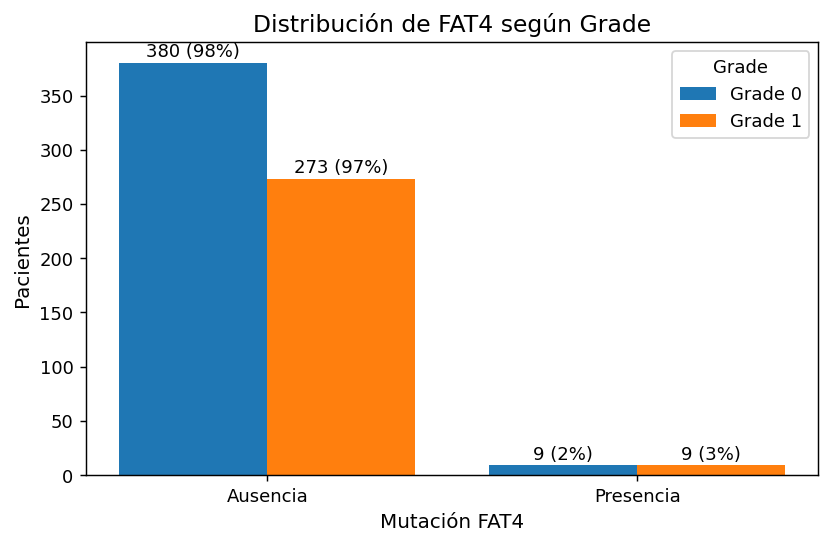
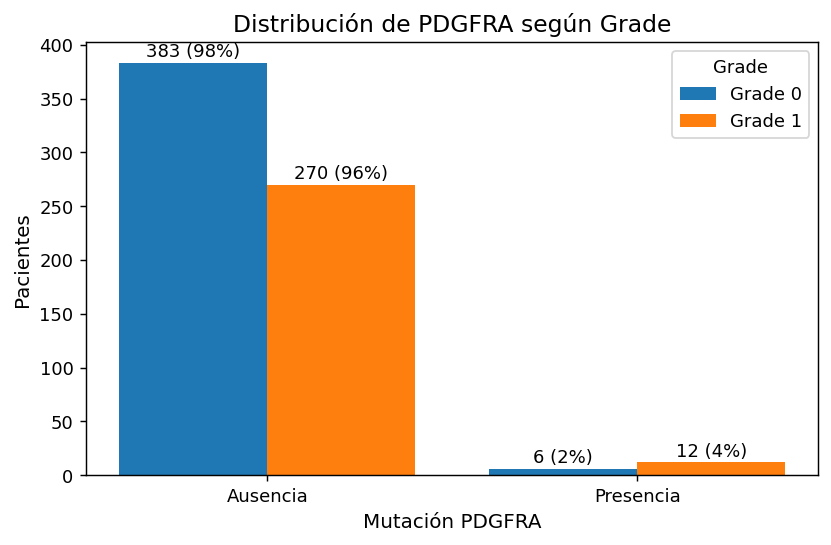

,Gen,Diferencia (pp)
0,ATRX,28.9
1,PTEN,27.9
2,CIC,21.8
3,EGFR,13.6
4,TP53,12.5
5,FUBP1,9.6
6,NOTCH1,8.5
7,RB1,8.1
8,MUC16,7.2
9,PIK3R1,4.6


In [16]:
genes_restantes = [v for v in variables_categoricas if v != "IDH1"]

resultados_genes = []
bloques_html = []

for gen in genes_restantes:

    df_plot = resumen_bivariado(
        train_data, target="Grade", variable=gen,
        etiquetas={0: "Ausencia", 1: "Presencia"}
    )

    imagen_base64 = graficar_bivariado_base64(
        df_plot, target="Grade", variable=gen,
        titulo=f"Distribución de {gen} según Grade",
        xlabel=f"Mutación {gen}"
    )

    texto, diff = generar_interpretacion(df_plot, target="Grade", variable=gen)

    resultados_genes.append({"Gen": gen, "Diferencia (pp)": diff})

    bloques_html.append(f"""
    <details class="gen-panel">
        <summary>{gen}</summary>
        <div class="gen-panel-body">
            <img src="data:image/png;base64,{imagen_base64}">
            <p>{texto}</p>
        </div>
    </details>
    """)

estilos = """
<style>
.gen-panel {
    margin-bottom: 12px;
    border: 1px solid rgba(148, 163, 184, 0.35);
    border-radius: 10px;
    padding: 14px 18px;
    background-color: rgba(148, 163, 184, 0.10);
    transition: background-color 0.2s ease;
}
.gen-panel[open] {
    background-color: rgba(148, 163, 184, 0.16);
    padding-bottom: 20px;
}
.gen-panel summary {
    cursor: pointer;
    font-weight: 600;
    font-size: 17px;
    list-style: none;
}
.gen-panel summary::-webkit-details-marker { display: none; }
.gen-panel summary::before {
    content: "▸ ";
    display: inline-block;
    transition: transform 0.15s ease;
}
.gen-panel[open] summary::before {
    transform: rotate(90deg);
}
.gen-panel-body {
    display: grid;
    grid-template-columns: 58% 42%;
    gap: 28px;
    align-items: center;
    margin-top: 18px;
}
.gen-panel-body img {
    width: 100%;
    height: auto;
    border-radius: 6px;
}
.gen-panel-body p {
    line-height: 1.7;
    font-size: 15.5px;
    margin: 0;
}
@media (max-width: 700px) {
    .gen-panel-body { grid-template-columns: 1fr; }
}
</style>
"""

display(HTML(estilos + "<div>" + "".join(bloques_html) + "</div>"))

# Resumen de fuerza de asociación por gen, ordenado de mayor a menor diferencia
resumen_diferencias = (
    pd.DataFrame(resultados_genes)
    .sort_values("Diferencia (pp)", ascending=False)
    .reset_index(drop=True)
)

resumen_diferencias


There is a lot more that you can do with outputs (such as including interactive outputs)
with your book. For more information about this, see [the Jupyter Book documentation](https://jupyterbook.org)